In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os


In [5]:
from matplotlib import pyplot as plt
from scipy import signal, stats
from scipy.fft import rfft, rfftfreq

In [6]:
# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------
 
SAMPLING_RATE = 50_000  # Hz

# names=['rot_freq', 'uhang_x', 'uhang_y', 'uhang_z', 'ohang_x', 'ohang_y', 'ohang_z', 'microphone'])

CHANNEL_NAMES = [
    "tachometer",
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
    "microphone",
]

# Accelerometer channels we extract vibration features from
ACCEL_CHANNELS = [
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
]
 
# Bearing geometry from the MaFaulDa documentation (MB ER-16K bearing).
# Used to compute characteristic fault frequencies.
BEARING = {
    "n_balls": 8,
    "ball_diameter_mm": 7.94,
    "pitch_diameter_mm": 33.50,
    "contact_angle_deg": 0.0,
}

In [ ]:
def estimate_rotation_frequency(tacho: np.ndarray, fs: int = SAMPLING_RATE) -> float:
    """
    Estimate shaft rotation frequency (Hz) from the tachometer channel.
 
    The tachometer in MaFaulDa is a 1-pulse-per-revolution signal, so the
    pulse repetition rate equals the rotation frequency. We detect the
    dominant peak in the FFT of the tachometer to get a robust estimate.
    """
    tacho = np.asarray(tacho, dtype=np.float64)
    tacho = tacho - tacho.mean()
    window = np.hanning(len(tacho))
    mag = np.abs(rfft(tacho * window))
    freqs = rfftfreq(len(tacho), d=1.0 / fs)
 
    # Restrict to a plausible rotation range (5–100 Hz covers MaFaulDa)
    valid = (freqs >= 5.0) & (freqs <= 100.0)
    if not valid.any():
        return 0.0
    idx_in_valid = np.argmax(mag[valid])
    return float(freqs[valid][idx_in_valid])

In [8]:
def time_domain_features(x: np.ndarray) -> dict:
    """Compute classical time-domain statistics from a 1D signal."""
    x = np.asarray(x, dtype=np.float64)
    abs_x = np.abs(x)
 
    mean = x.mean()
    std = x.std()
    rms = np.sqrt(np.mean(x ** 2))
    peak = abs_x.max()
    peak_to_peak = x.max() - x.min()
    mean_abs = abs_x.mean()
 
    # Guard against divide-by-zero on a flatlined channel
    crest_factor    = peak / rms      if rms      > 0 else 0.0
    shape_factor    = rms  / mean_abs if mean_abs > 0 else 0.0
    impulse_factor  = peak / mean_abs if mean_abs > 0 else 0.0
    sqrt_mean_sq    = np.mean(np.sqrt(abs_x)) ** 2
    margin_factor   = peak / sqrt_mean_sq if sqrt_mean_sq > 0 else 0.0
 
    # scipy.stats.kurtosis returns excess kurtosis by default (Gaussian = 0).
    # We add 3 so that a Gaussian signal reports kurtosis ≈ 3, the convention
    # used in most bearing-diagnostics papers.
    skewness = stats.skew(x)
    kurtosis = stats.kurtosis(x) + 3
 
    # Zero-crossing rate (crossings per second)
    zero_crossings = np.sum(np.diff(np.signbit(x))) / (len(x) / SAMPLING_RATE)
 
    return {
        "mean": mean,
        "std": std,
        "rms": rms,
        "peak": peak,
        "peak_to_peak": peak_to_peak,
        "crest_factor": crest_factor,
        "shape_factor": shape_factor,
        "impulse_factor": impulse_factor,
        "margin_factor": margin_factor,
        "skewness": skewness,
        "kurtosis": kurtosis,
        "zero_crossing_rate": zero_crossings,
    }

In [9]:
df = pd.read_csv('/kaggle/input/datasets/vuxuancu/mafaulda-full/mafaulda/normal/12.288.csv', names=CHANNEL_NAMES)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   tachometer            250000 non-null  float64
 1   underhang_axial       250000 non-null  float64
 2   underhang_radial      250000 non-null  float64
 3   underhang_tangential  250000 non-null  float64
 4   overhang_axial        250000 non-null  float64
 5   overhang_radial       250000 non-null  float64
 6   overhang_tangential   250000 non-null  float64
 7   microphone            250000 non-null  float64
dtypes: float64(8)
memory usage: 15.3 MB


In [10]:
# Estimate the rotation frequency once from the tachometer
f_r = estimate_rotation_frequency(df["tachometer"].values)
features = {"rotation_frequency": f_r}
 
for ch in ACCEL_CHANNELS:
        x = df[ch].values
 
        # Time-domain
        td = time_domain_features(x)
        for k, v in td.items():
            features[f"{ch}__{k}"] = v
 
        # Frequency-domain
        #freqs, mag = compute_spectrum(x)
        #fd = frequency_domain_features(freqs, mag)
        #for k, v in fd.items():
        #    features[f"{ch}__{k}"] = v
 
        # Fault-band features (use the rotation frequency from the tach)
        #fb = fault_band_features(freqs, mag, f_r)
        #for k, v in fb.items():
        #    features[f"{ch}__{k}"] = v

In [11]:
features

{'rotation_frequency': 24.200000000000003,
 'underhang_axial__mean': np.float64(-0.0026605632277908004),
 'underhang_axial__std': np.float64(0.9791741607223888),
 'underhang_axial__rms': np.float64(0.9791777752906179),
 'underhang_axial__peak': np.float64(3.1429),
 'underhang_axial__peak_to_peak': np.float64(4.6713000000000005),
 'underhang_axial__crest_factor': np.float64(3.2097337984077448),
 'underhang_axial__shape_factor': np.float64(1.1499745393716643),
 'underhang_axial__impulse_factor': np.float64(3.6911121463296084),
 'underhang_axial__margin_factor': np.float64(4.12469219786216),
 'underhang_axial__skewness': np.float64(-0.2965344871903829),
 'underhang_axial__kurtosis': np.float64(1.9342677699078201),
 'underhang_axial__zero_crossing_rate': np.float64(41169.6),
 'underhang_radial__mean': np.float64(-0.0006316400859228001),
 'underhang_radial__std': np.float64(0.30736994391002836),
 'underhang_radial__rms': np.float64(0.3073705929142411),
 'underhang_radial__peak': np.float64(

<function matplotlib.pyplot.show(close=None, block=None)>

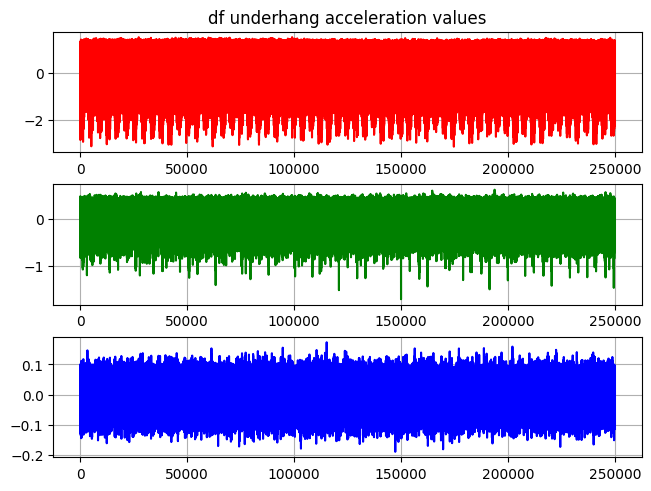

In [13]:
fig, ax = plt.subplots(3, 1, layout='constrained')
ax[0].set_title('df underhang acceleration values')
ax[0].plot(df.index.values, df[ACCEL_CHANNELS[0]].values, color='red')
ax[0].grid(True)
ax[1].plot(df.index.values, df[ACCEL_CHANNELS[1]].values, color='green')
ax[1].grid(True)
ax[2].plot(df.index.values, df[ACCEL_CHANNELS[2]].values, color='blue')
ax[2].grid(True)
plt.show

In [14]:
def plot_time_features(td_features):
    plt.plot(td_features["underhang_axial__mean"])
    

In [ ]:
# Estimate the rotation frequency once from the tachometer
f_r = estimate_rotation_frequency(df["tachometer"].values)
features = {"rotation_frequency": f_r}
 
for ch in ACCEL_CHANNELS:
        x = df[ch].values
 
        # Time-domain
        td = time_domain_features(x)
        for k, v in td.items():
            features[f"{ch}__{k}"] = v


/tmp/ipykernel_57/338909203.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_names, rotation=30, ha="right", fontsize=8)
/tmp/ipykernel_57/338909203.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_names, rotation=30, ha="right", fontsize=8)
/tmp/ipykernel_57/338909203.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_names, rotation=30, ha="right", fontsize=8)
/tmp/ipykernel_57/338909203.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_names, rotation=30, ha="right", fontsize=8)
/tmp/ipykernel_57/338909203.py:26: UserWarning: set_ticklabels()

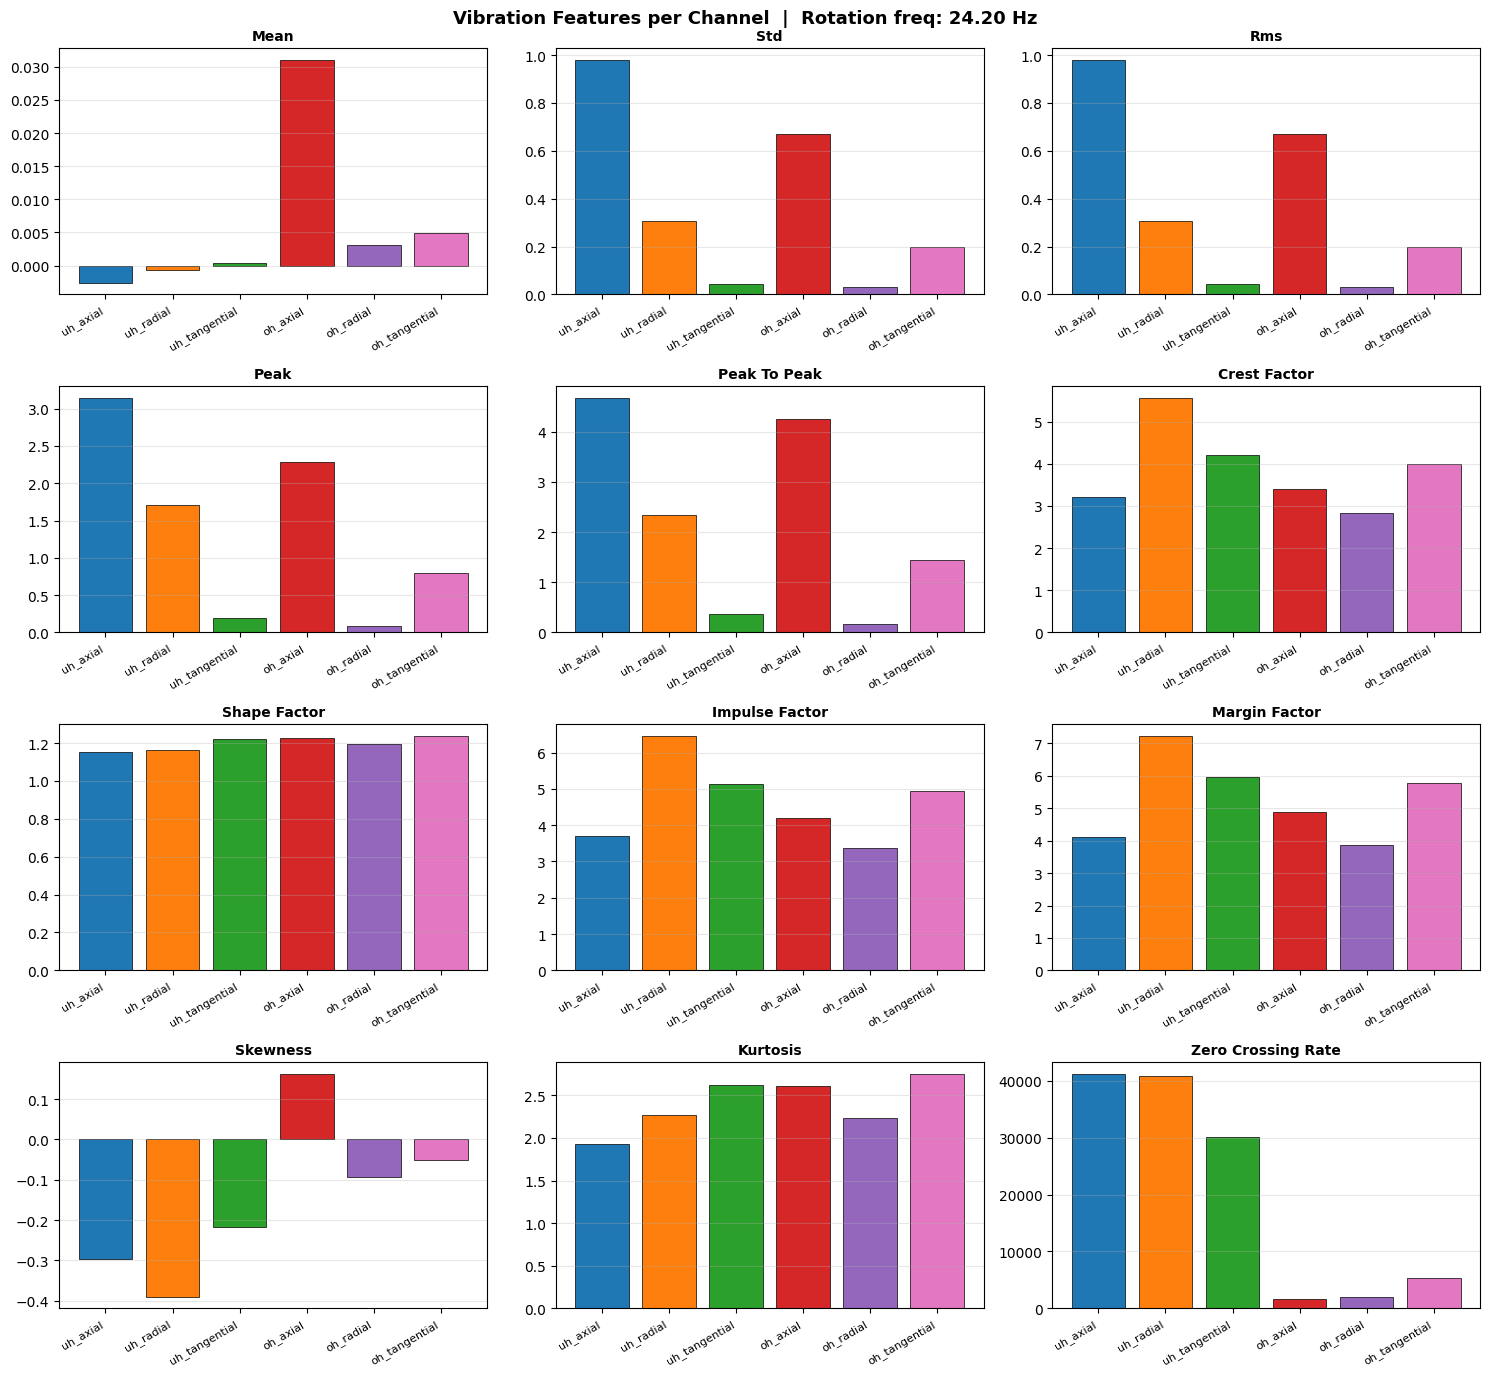

In [15]:
# Parse flat features dict → {feature: {channel: value}}
rot_freq = features["rotation_frequency"]

channel_features = {}
for key, val in features.items():
    if "__" in key:
        ch, feat = key.split("__", 1)
        channel_features.setdefault(feat, {})[ch] = float(val)

feat_names  = list(channel_features.keys())
channels    = list(next(iter(channel_features.values())).keys())
short_names = [ch.replace("underhang_", "uh_").replace("overhang_", "oh_") for ch in channels]

ncols  = 3
nrows  = (len(feat_names) + ncols - 1) // ncols
colors = plt.cm.tab10(np.linspace(0, 0.6, len(channels)))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(feat_names):
    ax   = axes[i]
    vals = [channel_features[feat][ch] for ch in channels]
    ax.bar(short_names, vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(feat.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_xticklabels(short_names, rotation=30, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"Vibration Features per Channel  |  Rotation freq: {rot_freq:.2f} Hz",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()
